 **Data Analytics Group assignment**

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
df = pd.read_excel(r"Crime.xls", skiprows=2, engine='openpyxl')

In [150]:
df.head()


,Iso3_code,Region,Subregion,Country,Source,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
0,ARM,Asia,Western Asia,Armenia,CTS,by citizenship,National citizens,Male,Total,2013,Counts,35.0
1,CHE,Europe,Western Europe,Switzerland,CTS,by citizenship,National citizens,Male,Total,2013,Counts,28.0
2,COL,Americas,Latin America and the Caribbean,Colombia,CTS,by citizenship,National citizens,Male,Total,2013,Counts,15053.0
3,CZE,Europe,Eastern Europe,Czechia,CTS,by citizenship,National citizens,Male,Total,2013,Counts,69.0
4,DEU,Europe,Western Europe,Germany,CTS,by citizenship,National citizens,Male,Total,2013,Counts,455.0


## Preliminary Questions
You are required to conduct a cursory examination of the dataset and identify a set of ten (10) to twelve (12) preliminary questions you would like to answer using the data. Add these questions to your Jupyter Notebook to guide your exploratory data analysis (EDA). As your understanding of the dataset improves, you may include additional questions. Later, your EDA should aim to answer eight (8) of these questions in detail.

By completing this step, you will have finished steps 1 and 2.

1.  Which countries have the highest and lowest homicide rates (per 100,000 population) in the most recent year available?
2.  How has the global homicide rate (or total counts) changed over time for the 'World' region?
3.  How do homicide rates compare across the five major regions (Americas, Europe, Asia, Africa, Oceania)?
4.  What is the distribution of homicide by mechanisms (e.g., 'Firearms or explosives', 'Another weapon') globally or by a specific region?
5.  Is there a significant difference in crime rates (either total or homicide) between male and female victims?
6.  Which age group has the highest number of homicide victims in the dataset?
7.  For a given country, how does the proportion of homicides committed by intimate partners or family members compare to those committed by unknown perpetrators?
8. How do the crime statistics differ between 'National citizens' and 'Foreign citizens' across a selected set of European countries?
9. Are there significant regional differences in the distribution of homicides based on the situational context (e.g., 'Interpersonal homicide', 'Socio-political homicide')?
10. Which subregions within a major region (e.g., Western Asia vs. Eastern Asia) show the largest disparity in their reported homicide rates?

In [151]:
df.shape

(118401, 12)

In [152]:
df.describe()


,Year,VALUE
count,118401.000000,118401.000000
mean,2015.155928,564.975430
std,6.169764,9146.483991
min,1990.000000,0.000000
25%,2012.000000,0.207600
50%,2017.000000,2.295671
75%,2020.000000,19.600807
max,2023.000000,451035.632884


In [153]:
df.describe(include='object')

,Iso3_code,Region,Subregion,Country,Source,Dimension,Category,Sex,Age,Unit of measurement
count,118401,118397,118397,118397,118401,118401,118401,118401,118401,118401
unique,215,6,23,214,246,6,24,3,11,2
top,CAN,Europe,Latin America and the Caribbean,Canada,CTS,Total,Total,Male,Total,Counts
freq,2204,51221,38929,2204,82308,65286,65286,40025,77625,63347


In [154]:
# df.info()
print(df.isnull().sum())

Iso3_code              0
Region                 4
Subregion              4
Country                4
Source                 0
Dimension              0
Category               0
Sex                    0
Age                    0
Year                   0
Unit of measurement    0
VALUE                  0
dtype: int64


# Data Preprocessing

## Making shallow copy of the Dataset

In [155]:
df_copy = df.copy()  # Making shallow copy of the Dataset

## Checking missing values

In [156]:
missing_val = df_copy[df_copy['Region'].isnull()]
missing_val

,Iso3_code,Region,Subregion,Country,Source,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
3140,,NaN,NaN,NaN,NP,Total,Total,Total,Total,2005,Counts,1.0
3273,,NaN,NaN,NaN,NP,Total,Total,Total,Total,2006,Counts,2.0
3567,,NaN,NaN,NaN,NP,Total,Total,Total,Total,2008,Counts,1.0
3897,,NaN,NaN,NaN,NP,Total,Total,Total,Total,2010,Counts,0.0


### Dropping Missing Values

In [157]:
# Dropping missing values in 'Region' column
df_copy = df_copy.dropna(subset=['Region'])

In [158]:

print(df_copy.isnull().sum())

Iso3_code              0
Region                 0
Subregion              0
Country                0
Source                 0
Dimension              0
Category               0
Sex                    0
Age                    0
Year                   0
Unit of measurement    0
VALUE                  0
dtype: int64


## Checking Duplicate

In [159]:
df_duplicates = df_copy[df_copy.duplicated()]
df_duplicates.shape

(2815, 12)

In [160]:
df_duplicates.head(10)

,Iso3_code,Region,Subregion,Country,Source,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
47451,ISL,Europe,Northern Europe,Iceland,CTS,by citizenship,National citizens,Male,Total,2013,Counts,1.0
47493,ISL,Europe,Northern Europe,Iceland,CTS,by citizenship,National citizens,Male,Total,2015,Counts,2.0
47533,LIE,Europe,Western Europe,Liechtenstein,CTS,by citizenship,National citizens,Male,Total,2016,Counts,0.0
47537,MAC,Asia,Eastern Asia,"China, Macao Special Administrative Region",CTS,by citizenship,National citizens,Male,Total,2016,Counts,1.0
47549,ARM,Asia,Western Asia,Armenia,CTS,by citizenship,National citizens,Male,Total,2017,Counts,59.0
47564,GRC,Europe,Southern Europe,Greece,CTS,by citizenship,National citizens,Male,Total,2017,Counts,41.0
47599,DMA,Americas,Latin America and the Caribbean,Dominica,CTS,by citizenship,National citizens,Male,Total,2018,Counts,12.0
47610,HUN,Europe,Eastern Europe,Hungary,CTS,by citizenship,National citizens,Male,Total,2018,Counts,42.0
47611,ISL,Europe,Northern Europe,Iceland,CTS,by citizenship,National citizens,Male,Total,2018,Counts,2.0
47620,MLT,Europe,Southern Europe,Malta,CTS,by citizenship,National citizens,Male,Total,2018,Counts,1.0


### Remove Duplicates

In [161]:
# Remove duplicates
df_copy = df_copy.drop_duplicates()

## Drop irrelevant Columns
- Sources
- VALUE

In [162]:

df_copy = df_copy.drop(columns=['Source'])

## Units of Measurement

In [163]:
# Units of measurement
df_per_100k = df_copy[df_copy['Unit of measurement'] == 'Rate per 100,000 population']
df_per_100k.shape

(54136, 11)

In [164]:
df_per_100k.head()

,Iso3_code,Region,Subregion,Country,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
63347,ABW,Americas,Latin America and the Caribbean,Aruba,Total,Total,Total,Total,1990,"Rate per 100,000 population",0.000000
63348,AIA,Americas,Latin America and the Caribbean,Anguilla,Total,Total,Total,Total,1990,"Rate per 100,000 population",0.000000
63349,ARM,Asia,Western Asia,Armenia,Total,Total,Total,Total,1990,"Rate per 100,000 population",5.011081
63350,ATG,Americas,Latin America and the Caribbean,Antigua and Barbuda,Total,Total,Total,Total,1990,"Rate per 100,000 population",1.585628
63351,AUS,Oceania,Australia and New Zealand,Australia,Total,Total,Total,Total,1990,"Rate per 100,000 population",2.183776


In [165]:
df_per_count = df_copy[df_copy['Unit of measurement'] == 'Counts']
# df_per_count.value_counts()
df_per_count.shape


(61446, 11)

In [166]:
df_per_count.head()

,Iso3_code,Region,Subregion,Country,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE
0,ARM,Asia,Western Asia,Armenia,by citizenship,National citizens,Male,Total,2013,Counts,35.0
1,CHE,Europe,Western Europe,Switzerland,by citizenship,National citizens,Male,Total,2013,Counts,28.0
2,COL,Americas,Latin America and the Caribbean,Colombia,by citizenship,National citizens,Male,Total,2013,Counts,15053.0
3,CZE,Europe,Eastern Europe,Czechia,by citizenship,National citizens,Male,Total,2013,Counts,69.0
4,DEU,Europe,Western Europe,Germany,by citizenship,National citizens,Male,Total,2013,Counts,455.0


# ANSWER TO QUESTIONS

## 1.  Which countries have the highest and lowest homicide rates (per 100,000 population) in the most recent year available?

In [172]:
# countries with highest and those with lowest homicide rates (per 100k population)
highest_homicide = df_per_100k.loc[df_per_100k.groupby('Year')['VALUE'].idxmax()]
lowest_homicide = df_per_100k.loc[df_per_100k.groupby('Year')['VALUE'].idxmin()]


### Countries with highest

In [174]:
highest_homicide[['Country', 'Year', 'VALUE']].head(10)

,Country,Year,VALUE
67605,Colombia,1990,138.875824
67644,Colombia,1991,159.867251
67681,Colombia,1992,154.779741
67724,Colombia,1993,153.396163
67768,Colombia,1994,143.360707
63922,El Salvador,1995,138.438378
67865,Colombia,1996,119.101172
67916,Colombia,1997,116.254730
67963,Colombia,1998,113.726922
68010,Colombia,1999,118.076529


### Countries with Lowest

In [175]:
lowest_homicide[['Country', 'Year', 'VALUE']].head(10)

,Country,Year,VALUE
63347,Aruba,1990,0.0
63491,Kiribati,1991,0.0
63535,Anguilla,1992,0.0
63687,Kiribati,1993,0.0
63730,Anguilla,1994,0.0
63883,Iceland,1995,0.0
63942,Anguilla,1996,0.0
64103,Kiribati,1997,0.0
64157,Anguilla,1998,0.0
64266,Anguilla,1999,0.0


### Plotting to countries and homicide rates per 100 000 population with Matplotlib and Seaborn

C:\Users\bgano\AppData\Local\Temp\ipykernel_21396\2484159792.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=df_per_100k['Country'].iloc[0], bbox_to_anchor=(1.05, 1), loc='upper left')


TypeError: xticks(): Parameter 'labels' can't be set without setting 'ticks'

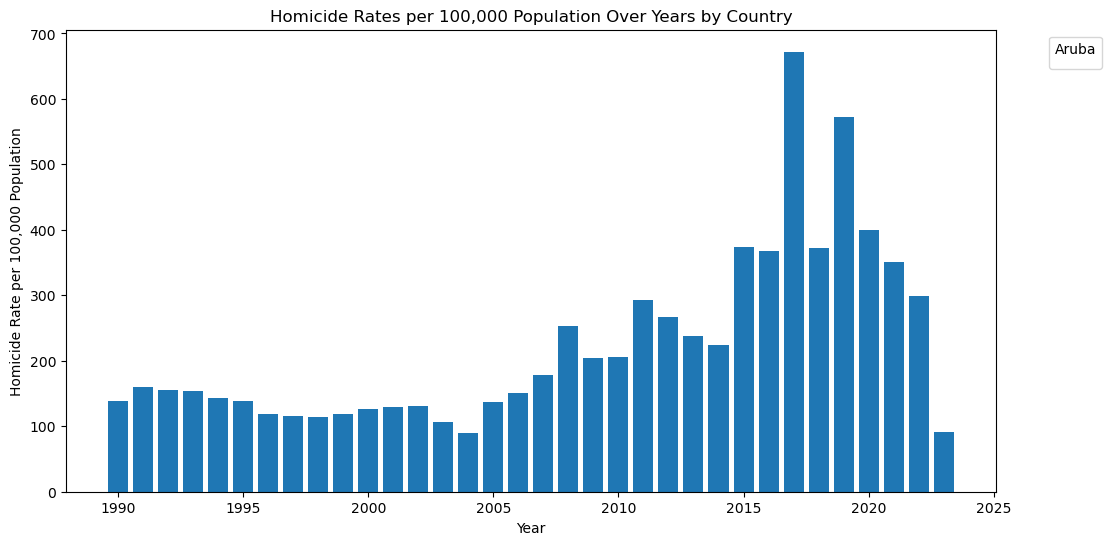

In [188]:
### Plotting to countries and homicide rates per 100 000 population with plt
plt.figure(figsize=(12, 6))
plt.bar(df_per_100k['Year'], df_per_100k['VALUE'])
plt.title('Homicide Rates per 100,000 Population Over Years by Country')
plt.xlabel('Year')
plt.ylabel('Homicide Rate per 100,000 Population')
plt.legend(title=df_per_100k['Country'].iloc[0], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()